# Fit attraverso integrazione della posterior

50.349999999999994 1.1704699910719614
-89.48750000000001 0.22603465810947773
548.7264042003706


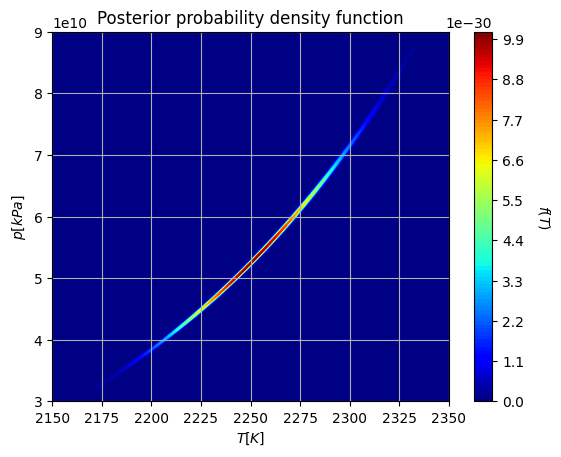

In [4]:
#FIT LINEARE CON MINIMI QUADRATI
import matplotlib.pyplot as plt

from matplotlib import cm

import numpy
from numpy import sqrt,floor

import numpy as np
import pandas as pd
import random
import math

# libreria locale
import my_lib_santanastasio as my
##NOTA IMPORTANTE: se cambi qualcosa in my_lib_santanastasio 
# devi fare Kernel --> Restart prima di rigirare il codice
# altrimenti i cambiamenti non saranno applicati.

from scipy import stats
import scipy.integrate as integrate
from scipy import optimize

def posterior(M, C, P, T, sigmaP):
    Yexp = C*np.exp(-M*18/8.1834/T)
    return np.prod(stats.norm.pdf(P, Yexp, sigmaP))

P0 = 101.57 #kPa
uP0 = 0.5

offset = 0.15
uOffset = 0.003

Delta_pressioni = np.array([-89.79, -89.30, -89.33, -89.53])
Temp_multiple = np.array([49, 50, 50.6, 51.8])
uTemp = np.std(Temp_multiple, ddof=1)
uPress = np.std(Delta_pressioni, ddof=1)
print(np.mean(Temp_multiple), uTemp)
print(np.mean(Delta_pressioni), uPress)
Temp = np.array([np.mean(Temp_multiple), 56, 59.4, 64.8, 69.8, 74.4, 79.6, 84.6, 90.4]) + 273.15
Press = np.array([np.mean(Delta_pressioni), -85.88, -83.39, -78.26, -72.56, -67.59, -59.69, -50.01, -36.88])
Press = (np.array(Press) - offset + P0) *1000
uPress = np.array(uPress)
uTemp = np.array(uTemp)
uPress = np.sqrt(uPress**2 + uOffset**2 + uP0**2)*1000

print(uPress)

uy_new = np.repeat(uPress, len(Press))


m_values = np.linspace(2150, 2350, 500)
c_values = np.linspace(3e10, 9e10, 500)

m_mesh, c_mesh = np.meshgrid(m_values, c_values)

posterior_values = np.zeros(len(m_values)*len(c_values))
idx = 0
for mval, cval in np.nditer([m_mesh,c_mesh]):
    posterior_values[idx]=posterior(M=mval, C=cval, T=Temp, sigmaP=uy_new, P=Press) 
    idx = idx + 1
posterior_mesh = posterior_values.reshape((len(c_values), len(m_values)))
fig = plt.figure()
ax1 = plt.contourf(m_mesh, c_mesh, posterior_mesh, cmap=cm.jet, levels=100)
cbar = plt.colorbar(ax1)
cbar.set_label('$f(T)$', rotation=270, labelpad=20)
plt.xlabel("$T [K]$")
plt.ylabel("$p [kPa]$")
plt.grid()
plt.title("Posterior probability density function")
plt.savefig("Fit_posterior_aria_tot.png")
plt.show()

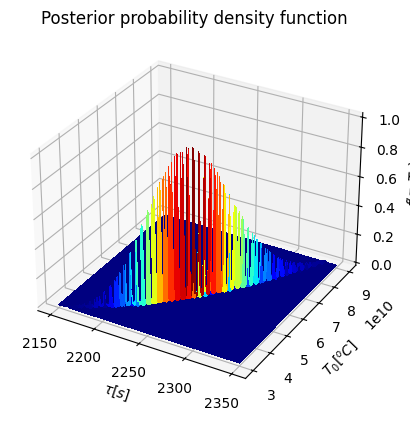

In [21]:
from matplotlib import cm
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(m_mesh, c_mesh, posterior_mesh, cmap=cm.jet,
                       linewidth=0, antialiased=False)

ax.set_xlabel('$\\tau [s]$')
ax.set_ylabel('$T_0 [^oC]$')
ax.set_zlabel('$f(\\tau,T_0)$')
plt.title("Posterior probability density function")
plt.savefig("grafico_3D.png")

In [22]:
range_m = (m_values[0], m_values[-1])
range_c = (c_values[0], c_values[-1])

# Integrale di normalizzazione della posterior
normalization, integral_error_norm = integrate.nquad(posterior, 
                                                    [range_m, #m
                                                     range_c  #c
                                                    ],
                                                    args=(Press ,Temp,uy_new)
                                                    )
print (normalization, integral_error_norm)

def posterior_norm(M,C,Y,X,SigmaY):    
    return posterior(M,C,Y,X,SigmaY) / normalization

def arg_E_c_k(M,C,k,Y,X,SigmaY):
    return C**k * posterior_norm(M,C,Y,X,SigmaY)

# L'argomento dell'integrale del valore atteso di m^k 
def arg_E_m_k(M,C,k,Y,X,SigmaY):
    return np.power(M,k) * posterior_norm(M,C,Y,X,SigmaY)

# L'argomento dell'integrale del valore atteso di m*c
def arg_E_mc(M,C,Y,X,SigmaY):
    return M * C * posterior_norm(M,C,Y,X,SigmaY)

def arg_Var_c(M, C, P, T, sigmaP, E_c):
    return (C - E_c)**2 * posterior_norm(M, C, P, T, sigmaP)

def arg_Var_m(M, C, P, T, sigmaP, E_m):
    return (M - E_m)**2 * posterior_norm(M, C, P, T, sigmaP)

4.673664281331008e-19 4.792716361669268e-19


In [23]:
E_c, error_int_E_c = integrate.nquad(arg_E_c_k, 
                                    [range_m, #m
                                    range_c  #c
                                    ],
                                    args=(1,Press, Temp, uy_new)#k=1
                                    )

Var_c, err_var = integrate.nquad(
    arg_Var_c,
    [range_m, range_c],
    args=(Press, Temp, uy_new, E_c)
)

Sigma_c = math.sqrt(Var_c)

In [24]:
E_m, error_int_E_m = integrate.nquad(arg_E_m_k, 
                                    [range_m, #m
                                    range_c  #c
                                    ],
                                    args=(1,Press, Temp, uy_new)#k=1
                                    )
Var_m, err_var = integrate.nquad(
    arg_Var_m,
    [range_m, range_c],
    args=(Press, Temp, uy_new, E_m)
)
Sigma_m = math.sqrt(Var_m)

In [25]:
E_mc, error_int_E_mc = integrate.nquad(arg_E_mc, 
                                       [range_m, #m
                                        range_c  #c
                                        ],
                                        args=(Press, Temp, uy_new)
                                        )
Cov_mc = E_mc - E_m*E_c
Rho_mc = Cov_mc / (Sigma_m*Sigma_c)

In [ ]:
print(f"\n\nm_fit = {E_m:.20f} \\pm {Sigma_m:.20f} [y/x] [{Sigma_m/E_m*100:.2f}%]\n")
print(f"c_fit = {E_c:.20f} \\pm {Sigma_c:.20f} [y] [{Sigma_c/E_c*100:.2f}%]\n")
print(f"Cov[m,c] fit  = {Cov_mc}\n")
print(f"Rho[m,c] fit  = {Rho_mc}\n")

t_pred = E_c*np.exp(-E_m*18/8.1834/Temp)
residuals = t_pred - Press
print(np.sum(residuals**2/uy_new**2)/(len(Press) - 2))


sigmy_post = np.sqrt( np.sum(residuals**2)/(residuals.size-2) )
uy_post = np.repeat(sigmy_post,Temp.size)




m_fit = 1785.09661461416294514493 \pm 473.59093518771629760522 [y/x] [26.53%]

c_fit = 58422960410.76809692382812500000 \pm 10511164549.71062469482421875000 [y] [17.99%]

Cov[m,c] fit 27821412974479.453

Rho[m,c] fit 5.588882341071474

2048099.7495959045


# Distribuzione marginale di c

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/var/folders/h7/5fmdn1ys2_g27vgk683vmkc80000gn/T/ipykernel_98730/1466497500.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(x = E_c+Sigma_c, color = 'orange', linestyle='--', label='$E[c] \pm 1\sigma$')


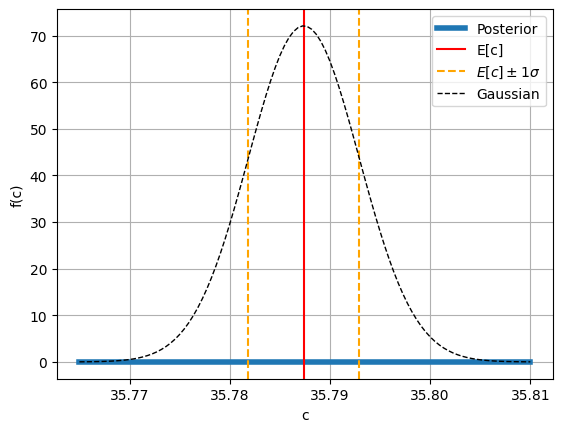

In [95]:
def posterior_1(M, C, T, t, sigmaT, Tf):
    Yexp = Tf - (Tf - C)*np.exp(-t/M)
    return np.prod(stats.norm.pdf(T, Yexp, sigmaT))

def posterior_1_norm(M,C,T,t,SigmaT, Tf):    
    return posterior_1(M,C,T,t,SigmaT, Tf) / normalization

posterior_norm_c = lambda C: integrate.nquad(posterior_1_norm, [range_m], args=(C,Temp,time,uy_new, Tf))[0]
posterior_norm_c_vfunc = np.vectorize(posterior_norm_c)

posterior_norm_c_values = posterior_norm_c_vfunc(c_values)

plt.plot(c_values,posterior_norm_c_values,label='Posterior',linewidth=4)
plt.xlabel("c")
plt.ylabel("f(c)")
plt.axvline(x = E_c, color = 'r', linestyle='-',label='E[c]')
plt.axvline(x = E_c+Sigma_c, color = 'orange', linestyle='--', label='$E[c] \pm 1\sigma$')
plt.axvline(x = E_c-Sigma_c, color = 'orange', linestyle='--')
plt.plot(c_values, stats.norm.pdf(c_values,E_c,Sigma_c), linewidth=1, color='black',linestyle='--',label='Gaussian')
plt.legend()
plt.grid()

# Distribuzione marginale di m

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/var/folders/h7/5fmdn1ys2_g27vgk683vmkc80000gn/T/ipykernel_98730/4060162081.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(x = E_m+Sigma_m, color = 'orange', linestyle='--', label='$E[m] \pm 1\sigma$')


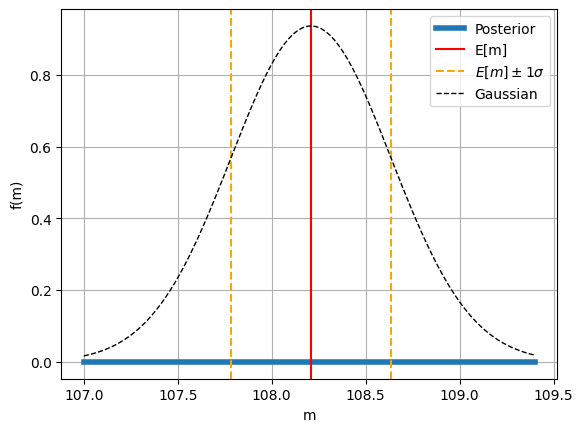

In [96]:
def posterior_2(C, M, T, t, sigmaT, Tf):
    Yexp = Tf - (Tf - C)*np.exp(-t/M)
    return np.prod(stats.norm.pdf(T, Yexp, sigmaT))

def posterior_2_norm(C, M, T, t, sigmaT, Tf):    
    return posterior_2(M, C, T, t, sigmaT, Tf) / normalization

posterior_norm_m = lambda M: integrate.nquad(posterior_2_norm, [range_c], args=(M, Temp, time, uy_new, Tf))[0]
posterior_norm_m_vfunc = np.vectorize(posterior_norm_m)

posterior_norm_m_values = posterior_norm_m_vfunc(m_values)

plt.plot(m_values,posterior_norm_m_values,label='Posterior',linewidth=4)
plt.xlabel("m")
plt.ylabel("f(m)")
plt.axvline(x = E_m, color = 'r', linestyle='-',label='E[m]')
plt.axvline(x = E_m+Sigma_m, color = 'orange', linestyle='--', label='$E[m] \pm 1\sigma$')
plt.axvline(x = E_m-Sigma_m, color = 'orange', linestyle='--')
plt.plot(m_values, stats.norm.pdf(m_values,E_m,Sigma_m), linewidth=1, color='black',linestyle='--',label='Gaussian')
plt.legend()
plt.grid()

